<a href="https://colab.research.google.com/github/jecampagne/toysysterror/blob/main/ToyModelSyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import matplotlib.lines as lines
mpl.rcParams["font.size"] = 16
mpl.rcParams['axes.titlesize'] = 16
plt.rcParams['image.cmap'] = 'RdBu_r'
from matplotlib.ticker import MultipleLocator
from matplotlib.collections import PathCollection

# Toy example
- Fit data with a wrong model
- Statistics of the over-dispersed Chi2

In [40]:
from tqdm import tqdm

In [41]:
from numpy.random import RandomState
rng = RandomState(12345)

In [42]:
from scipy.stats import norm, poisson, chi2, linregress

In [43]:
from sklearn import linear_model
from sklearn.preprocessing import PolynomialFeatures
glmPreg = linear_model.PoissonRegressor()
lmreg  = linear_model.LinearRegression()

# Utils

In [78]:
def C(y,mu):
  return 2*np.sum(y*np.log(y/mu)-(y-mu))  # Eq 3

def musigma_c(N,f,mu, hatmu=None,  kurtosis=3):
  f_vec = np.full(N, f) if np.isscalar(f) else np.asarray(f)
  mu_vec = np.full(N, mu) if np.isscalar(mu) else np.asarray(mu)
  #
  f_vec = f_vec.squeeze()
  mu_vec = mu_vec.squeeze()
  mu_c = np.sum(f_vec**2 * mu_vec)  # Eq 16
  sigc2 = 4 * mu_c + np.sum(f_vec**4 * ((mu_vec**2 + mu_vec) * kurtosis - mu_vec**2)) # Eq 18
  if hatmu is not None:
    hatmu_vec = hatmu.squeeze()
    sigc2 += 4 * np.sum(f_vec**2 * (hatmu_vec-mu_vec)**2)
  return mu_c, np.sqrt(sigc2)

# An example

In [45]:
def data_model(x,params):
  a,b,c = params
  return a * x**2 + b * x + c

In [46]:
Ndata = 100

In [47]:
x = np.arange(Ndata)
x = x - np.mean(x)
x = x[:,np.newaxis]

In [48]:
mu_true = data_model(x,[0.01, 0.1, 100])
y=poisson.rvs(mu=mu_true,random_state=rng)

In [49]:
# wrong linear fit model
lmreg  = linear_model.LinearRegression()
lmreg.fit(x,y);
mu_hat_bad = lmreg.predict(x)

In [50]:
print(C(y,mu_hat_bad))

138.2503210850335


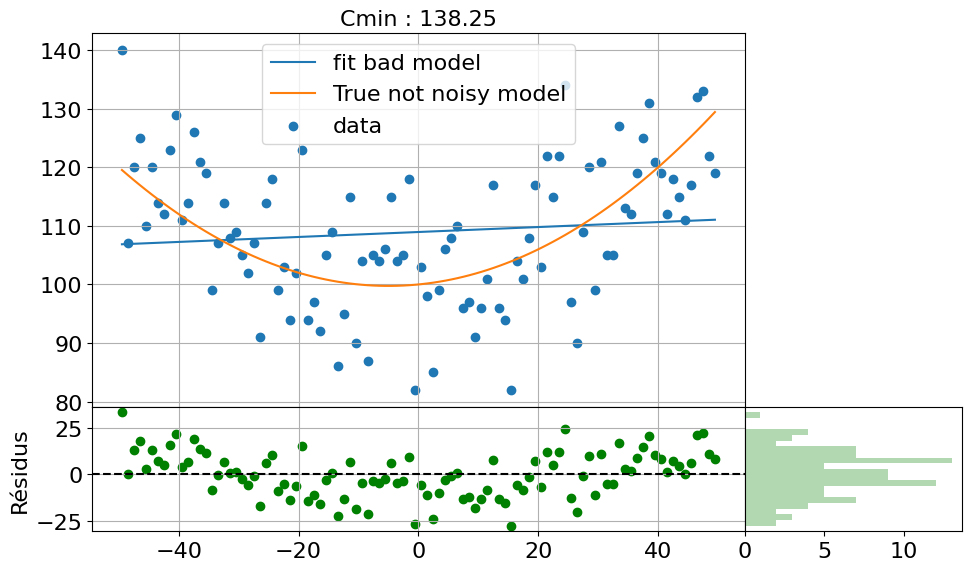

In [51]:
from matplotlib.gridspec import GridSpec
#fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.0})
fig = plt.figure(figsize=(10, 6))
gs = GridSpec(2, 2, height_ratios=[3, 1], width_ratios=[3, 1], hspace=0.0, wspace=0.0)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x, mu_hat_bad, label="fit bad model")
ax1.plot(x,mu_true,label="True not noisy model")
ax1.scatter(x,y,label='data')
ax1.legend()
ax1.grid()
ax1.set_title(f"Cmin : {C(y,mu_hat_bad):.2f}");

ax2 = fig.add_subplot(gs[1, 0])
residus = y-mu_hat_bad
ax2.scatter(x, residus, color='green')
ax2.axhline(y=0, color='black', linestyle='--')
ax2.grid()
ax2.set_yticks([-25, 0, 25])
ax2.set_ylabel('Résidus')

ax_hist = fig.add_subplot(gs[1, 1], sharey=ax2)
n, bins, patches = ax_hist.hist(residus, bins=20, color='green', alpha=0.3, orientation='horizontal')
ax_hist.set_ylim(ax2.get_ylim())

ax_hist.tick_params(axis='y', which='both', left=False, labelleft=False)


# Ajustement des marges
plt.subplots_adjust(hspace=0, wspace=0)
plt.tight_layout()




In [52]:
degree = 2
poly_features = PolynomialFeatures(degree=degree, include_bias=False)
x_poly = poly_features.fit_transform(x)
lmreg  = linear_model.LinearRegression()
lmreg.fit(x_poly,y);
mu_hat_good = lmreg.predict(x_poly)

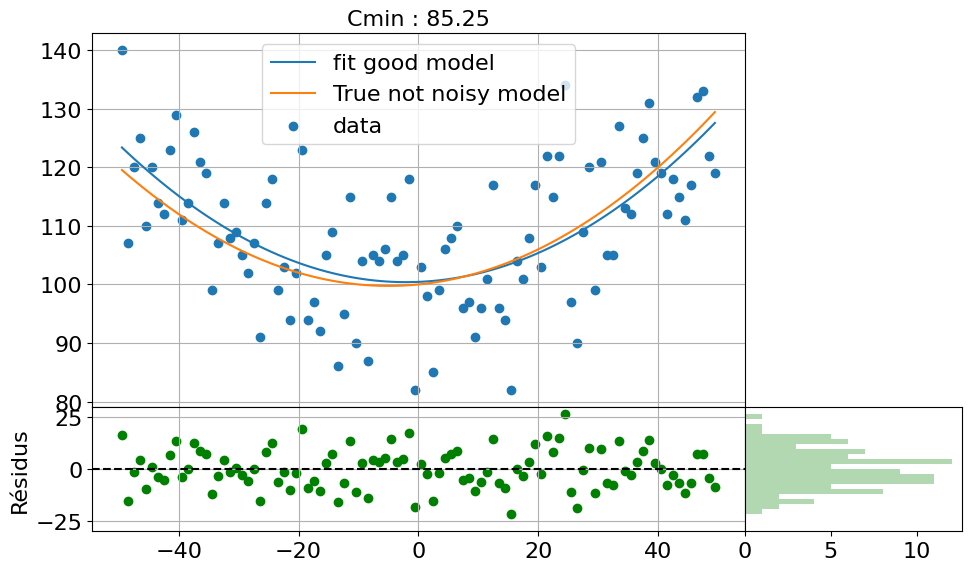

In [53]:
fig = plt.figure(figsize=(10, 6))
gs = GridSpec(2, 2, height_ratios=[3, 1], width_ratios=[3, 1], hspace=0.0, wspace=0.0)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x, mu_hat_good, label="fit good model")
ax1.plot(x,mu_true,label="True not noisy model")
ax1.scatter(x,y,label='data')
ax1.legend()
ax1.grid()
ax1.set_title(f"Cmin : {C(y,mu_hat_good):.2f}");

ax2 = fig.add_subplot(gs[1, 0])
residus = y-mu_hat_good
ax2.scatter(x, residus, color='green')
ax2.grid()
ax2.axhline(y=0, color='black', linestyle='--')
ax2.set_ylabel('Résidus')
ax2.set_ylim([-30,30])

ax_hist = fig.add_subplot(gs[1, 1], sharey=ax2)
n, bins, patches = ax_hist.hist(residus, bins=20, color='green', alpha=0.3, orientation='horizontal')
ax_hist.set_ylim(ax2.get_ylim())

ax_hist.tick_params(axis='y', which='both', left=False, labelleft=False)

# Ajustement des marges
plt.subplots_adjust(hspace=0, wspace=0)
plt.tight_layout()



# Experiment

In [54]:
def simul(Ndata, model_params, nloops=500, rng = RandomState(12345)):
  x = np.arange(Ndata)
  x = x - np.mean(x)
  x = x[:,np.newaxis]

  #for true model fit
  degree = 2
  poly_features = PolynomialFeatures(degree=degree, include_bias=False)
  x_poly = poly_features.fit_transform(x)

  mu_true = data_model(x,model_params) # the true mu_i

  Z_all = []
  X_all = []
  for i in tqdm(range(nloops)):
    y=poisson.rvs(mu=mu_true,random_state=rng)
    # wrong linear fit model
    lmreg  = linear_model.LinearRegression()
    lmreg.fit(x,y);
    mu_hat_bad = lmreg.predict(x)
    Z = C(y,mu_hat_bad)  # C_min,sys
    Z_all.append(Z)

    # true model fit
    lmreg  = linear_model.LinearRegression()
    lmreg.fit(x_poly,y);
    mu_hat_good = lmreg.predict(x_poly)
    X = C(y,mu_hat_good)  # C_min
    X_all.append(X)
  # end
  return np.array(X_all), np.array(Z_all), mu_true


In [55]:
Ndata = 100
model_params = [0.01, 0.1, 100]  # [a,b,c] s.t a * x**2 + b * x + c
X_all, Z_all, mu_true = simul(Ndata, model_params, nloops=10000)

100%|██████████| 10000/10000 [00:39<00:00, 253.31it/s]


In [56]:
from sklearn.mixture import GaussianMixture

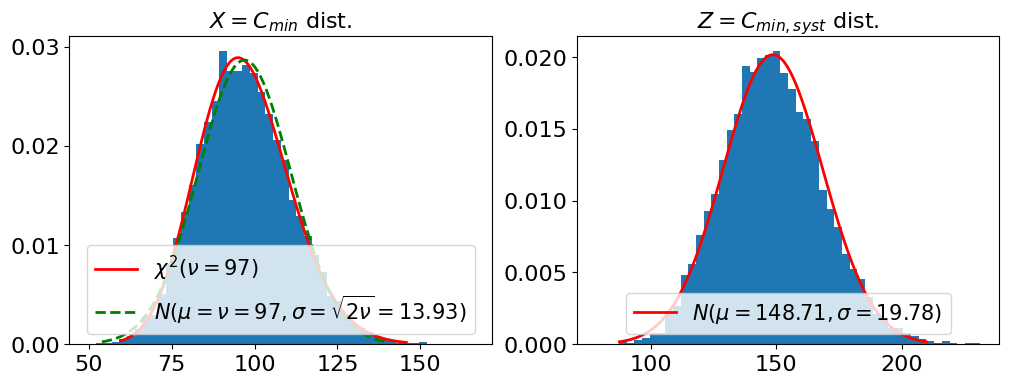

In [57]:
fig, axs = plt.subplots(1,2, figsize=(2*6,4))

axs[0].hist(X_all,bins=50,density=True);
dof = Ndata-3
rv = chi2(dof)
xvals = np.linspace(chi2.ppf(0.001, dof), chi2.ppf(0.999, dof), 100)
axs[0].plot(xvals, rv.pdf(xvals), 'r-', lw=2, label=fr'$\chi^2(\nu={dof})$')
rv = norm(loc=dof,scale=np.sqrt(2*dof))
xvals = np.linspace(norm.ppf(0.001, loc=dof,scale=np.sqrt(2*dof)),
                    norm.ppf(0.999, loc=dof,scale=np.sqrt(2*dof)), 100)
axs[0].plot(xvals, rv.pdf(xvals), 'g--', lw=2, label=fr'$N(\mu=\nu={dof},\sigma=\sqrt{{2\nu}}={np.sqrt(2*dof):.2f})$')
axs[0].set_title(r"$X=C_{min}$ dist.")
axs[0].legend(loc="lower center",fontsize=15);

counts, bins, _= axs[1].hist(Z_all,bins=50,density=True);
axs[1].set_title(r"$Z=C_{min,syst}$ dist.")

# Ajustement d'un mélange de 1 gaussienne (pour une seule gaussienne)
gmm = GaussianMixture(n_components=1, covariance_type='full')
gmm.fit(Z_all.reshape(-1, 1))
mu_Z, sigma_Z = gmm.means_[0, 0], np.sqrt(gmm.covariances_[0, 0, 0])
rv = norm(loc=mu_Z,scale=sigma_Z)
xvals = np.linspace(norm.ppf(0.001, loc=mu_Z,scale=sigma_Z),
                    norm.ppf(0.999, loc=mu_Z,scale=sigma_Z), 100)
axs[1].plot(xvals, rv.pdf(xvals), 'r-', lw=2, label=fr'$N(\mu={mu_Z:.2f},\sigma={sigma_Z:.2f})$')
axs[1].legend(loc="lower center",fontsize=15);

In [58]:
import  statsmodels.api as sm
import scipy.stats as stats

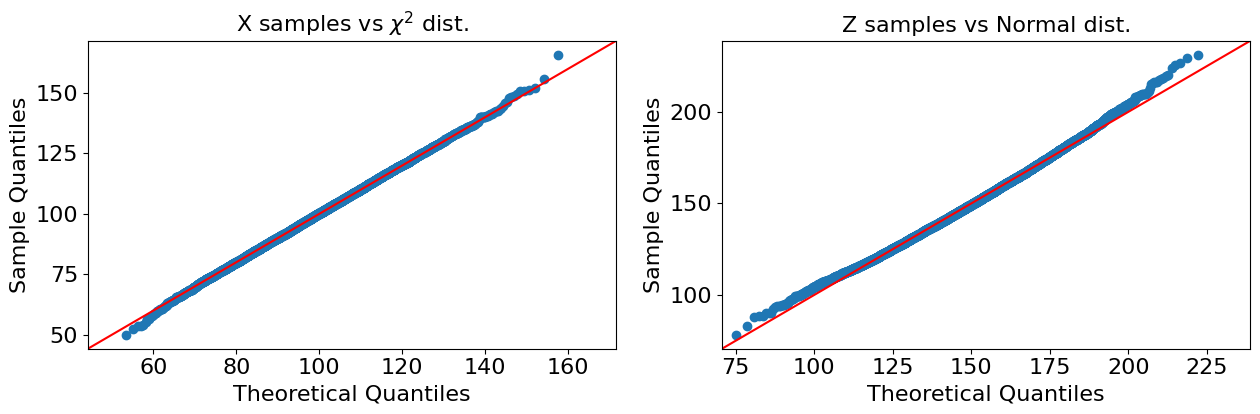

In [59]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15,4))

sm.qqplot(X_all, stats.distributions.chi2, distargs=(dof,), line="45" , ax=ax1)
ax1.set_title(r"X samples vs $\chi^2$ dist.")

sm.qqplot(Z_all, stats.distributions.norm, loc=mu_Z, scale=sigma_Z, line="45" , ax=ax2)
ax2.set_title(r"Z samples vs Normal dist.")


plt.show()

In [60]:
dof = Ndata-2  # here the wrong model as m=2 parameters
#mu_Z = dof + hat_mu_c
hat_mu_c = mu_Z - dof
# sigma_Z^2 = 2 dof + hat_sigma_c^2
sigma2_c = sigma_Z**2 - 2*dof
hat_sigma_c = np.sqrt(sigma2_c)
print(hat_mu_c, hat_sigma_c)

50.71214746052689 13.973674944155087


In [61]:
#direct fit of a gaussian on Y stat
Y_all = Z_all-X_all

gmm = GaussianMixture(n_components=1, covariance_type='full')
gmm.fit(Y_all.reshape(-1, 1))
hat_mu_c, hat_sigma_c = gmm.means_[0, 0], np.sqrt(gmm.covariances_[0, 0, 0])
hat_mu_c, hat_sigma_c

(np.float64(51.59291626861533), np.float64(14.126665460035706))

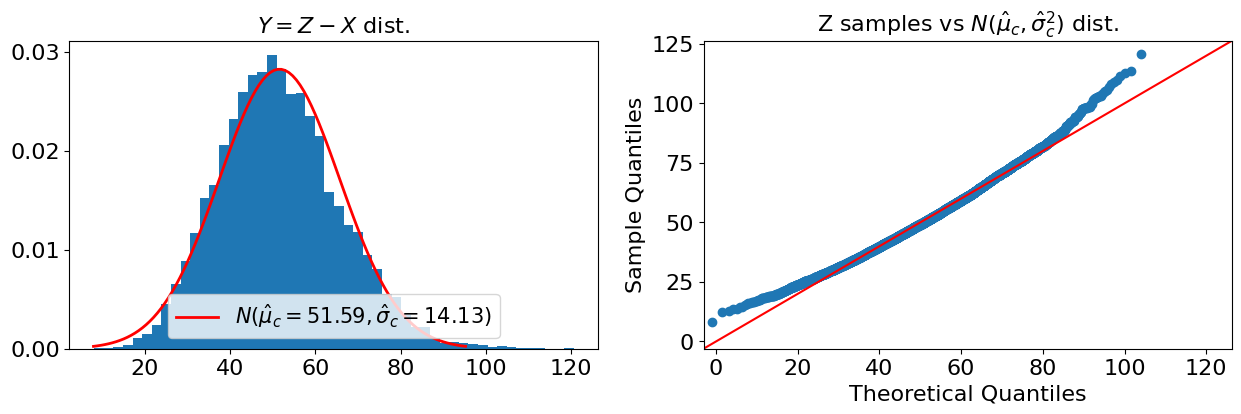

In [62]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15,4))


ax1.hist(Y_all,bins=50,density=True);
rv = norm(loc=hat_mu_c,scale=hat_sigma_c)
xvals = np.linspace(norm.ppf(0.001, loc=hat_mu_c,scale=hat_sigma_c),
                    norm.ppf(0.999, loc=hat_mu_c,scale=hat_sigma_c), 100)
ax1.plot(xvals, rv.pdf(xvals), 'r-', lw=2, label=fr'$N(\hat{{\mu}}_c={hat_mu_c:.2f},\hat{{\sigma}}_c={hat_sigma_c:.2f})$')
ax1.set_title(r"$Y=Z-X$ dist.");
ax1.legend(loc="lower center",fontsize=15);

sm.qqplot(Y_all, stats.distributions.norm, loc=hat_mu_c, scale=hat_sigma_c, line="45" , ax=ax2)
ax2.set_title(r"Z samples vs $N(\hat{{\mu}}_c,\hat{\sigma}_c^2)$ dist.");


In [63]:
f_approx = np.sqrt(hat_mu_c/np.sum(mu_true))
print(f"level of syst. (= f) = {100*f_approx:.2f}%")
y=poisson.rvs(mu=mu_true,random_state=rng)
f_approx1 = np.sqrt(hat_mu_c/np.sum(y))
print(f"level of syst. (= f) = {100*f_approx1:.2f}%")

level of syst. (= f) = 6.90%
level of syst. (= f) = 6.90%


In [79]:
y=poisson.rvs(mu=mu_true,random_state=rng)
lmreg  = linear_model.LinearRegression()
lmreg.fit(x,y);
mu_hat_bad = lmreg.predict(x)
c_minsys = C(y,mu_hat_bad)
print("C_minsyst =",c_minsys)
hat_mu_c = c_minsys - (Ndata-3)
print("hat_mu_c=",hat_mu_c)
f_approx = np.sqrt(hat_mu_c/np.sum(y))

tmp,hat_sigma_c = musigma_c(Ndata,f_approx,y)
print(hat_mu_c, tmp,hat_sigma_c**2, f_approx)

C_minsyst = 152.55899304008756
hat_mu_c= 55.55899304008756
55.55899304008756 55.558993040087564 285.7907455620287 0.0718573252327083


In [66]:
print(fr"\hat{{f}}^2 = {f_approx**2:.2e} \pm {std_fhat2:.2e}")

\hat{f}^2 = 2.23e-03 \pm 1.59e-03


In [67]:
print(fr"\hat{{f}} = {f_approx:.2e} \pm {std_fhat2/(2*f_approx):.2e}")

\hat{f} = 4.72e-02 \pm 1.68e-02


Fitting with the liear model is as if we have y_i ~ Poisson(M_i)
with E(M_i) = mu_i  (ie. true data model)
but Var(M_i) = sigma_i_sys^2 such that
\sigma_i_sys = f * true_mu_i

# EXtra
In fact Z= C_min,siys ~ B(nu,hat_mu_c, sigma_c^2) with B the convolution of Chi2(nu) with Normal(hat_mu_c, sigma_c^2) which is  known as the overdispersed chi-squared distribution.

In [68]:
# high precision math lib  (scipy would crash with the same argument)
from  mpmath import pcfd,exp    # pcfd = D_n(z) = U(-n-1/2,z) parabolic cylinder function

In [69]:
v_pcfd = np.vectorize(pcfd)   # mpmath does use numpy broadcasting
v_exp =  np.vectorize(exp)

In [70]:
# see Bonamente  & Zimmerman (2024) https://arxiv.org/pdf/2402.11088

def E(z,mu,sig):
  sig2 = sig**2
  lnE = sig2/8 - ((sig2 + 2 * (z-mu))/(4*sig))**2
  return v_exp(lnE)

def D(z,p):
  return v_pcfd(p,z)

def fB(z,nu,mu,sig2):
  sig = np.sqrt(sig2)
  norm = 2**(nu/2)*np.sqrt(2*np.pi)*sig**(1-nu/2)
  norm = 1./norm
  zeta = sig/2 + (mu-z)/sig
  A0 = E(z,mu,sig)
  A1 = D(zeta,-nu/2)
  return norm * A0  * A1



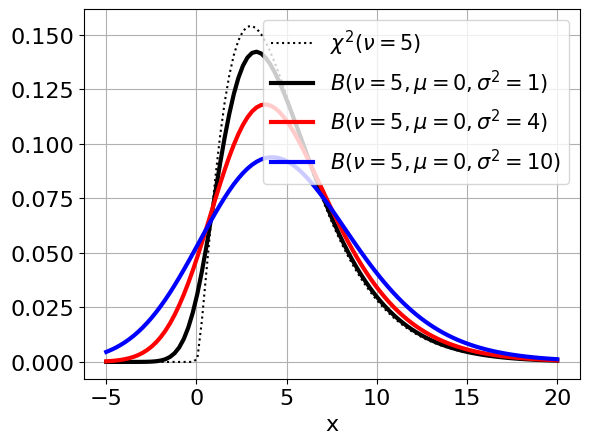

In [71]:
# exemple
xv=np.linspace(-5,20,100)
rv = chi2(5)
plt.plot(xv, rv.pdf(xv), 'k',ls="dotted", label=fr'$\chi^2(\nu=5)$')
plt.plot(xv,fB(xv,5,0,1),'k-',lw=3,label=fr"$B(\nu=5,\mu=0,\sigma^2=1)$")
plt.plot(xv,fB(xv,5,0,4),'r-',lw=3,label=fr"$B(\nu=5,\mu=0,\sigma^2=4)$")
plt.plot(xv,fB(xv,5,0,10),'b-',lw=3,label=fr"$B(\nu=5,\mu=0,\sigma^2=10)$");
plt.legend(fontsize=15)
plt.grid();
plt.xlabel("x");

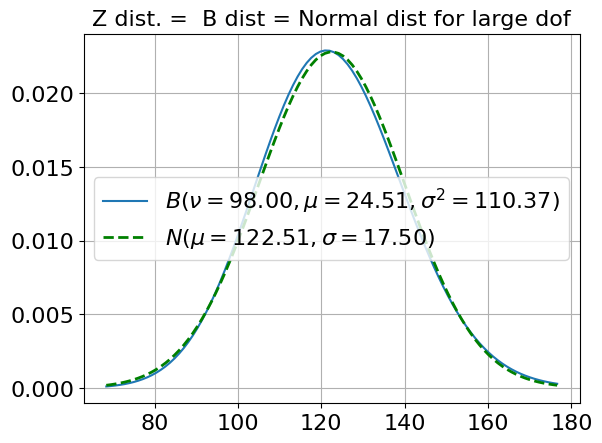

In [72]:
nu = Ndata-2
mu = hat_mu_c
sig2 = hat_sigma_c**2

mean_z = nu+mu
sigma_z = np.sqrt(2*nu+sig2)

rv = norm(loc=mean_z,scale=sigma_z)
xv = np.linspace(norm.ppf(0.001, loc=mean_z,scale=sigma_z),
                    norm.ppf(0.999, loc=mean_z,scale=sigma_z), 100)
yv = fB(xv,nu,mu,sig2)
plt.plot(xv,yv,label=fr"$B(\nu={nu:.2f},\mu={mu:.2f},\sigma^2={sig2:.2f})$")
plt.plot(xv, rv.pdf(xv), 'g--', lw=2, label=fr'$N(\mu={mean_z:.2f},\sigma={sigma_z:.2f})$')
plt.legend();
plt.title("Z dist. =  B dist = Normal dist for large dof")
plt.grid();